In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from tensorflow import keras
from tensorflow.keras import layers

train_df = pd.read_csv("fashion-mnist_train.csv")
test_df = pd.read_csv("fashion-mnist_test.csv")

In [2]:
train_df = train_df.sample(
    n=5000,
    random_state=42
)

In [3]:
X_train = train_df.drop("label", axis=1).values
y_train = train_df["label"].values

X_test = test_df.drop("label", axis=1).values
y_test = test_df["label"].values

In [4]:
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

In [5]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

In [6]:
n_classes = len(np.unique(y_train))

n_classes

10

In [7]:
model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(
        32,
        (3, 3),
        activation="relu"
    ),

    layers.MaxPooling2D(),

    layers.Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),

    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(
        64,
        activation="relu"
    ),

    layers.Dense(
        n_classes,
        activation="softmax"
    )
])

In [8]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [9]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.6570 - loss: 0.9960 - val_accuracy: 0.7260 - val_loss: 0.7113
Epoch 2/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - accuracy: 0.7803 - loss: 0.5942 - val_accuracy: 0.7750 - val_loss: 0.6039
Epoch 3/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.8188 - loss: 0.4969 - val_accuracy: 0.7950 - val_loss: 0.5361
Epoch 4/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.8403 - loss: 0.4460 - val_accuracy: 0.8090 - val_loss: 0.5049
Epoch 5/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - accuracy: 0.8602 - loss: 0.3994 - val_accuracy: 0.8160 - val_loss: 0.5327


In [10]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test
)

test_accuracy

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8297 - loss: 0.5041


0.8296999931335449

In [11]:
predictions = model.predict(X_test)

predicted_labels = np.argmax(
    predictions,
    axis=1
)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step


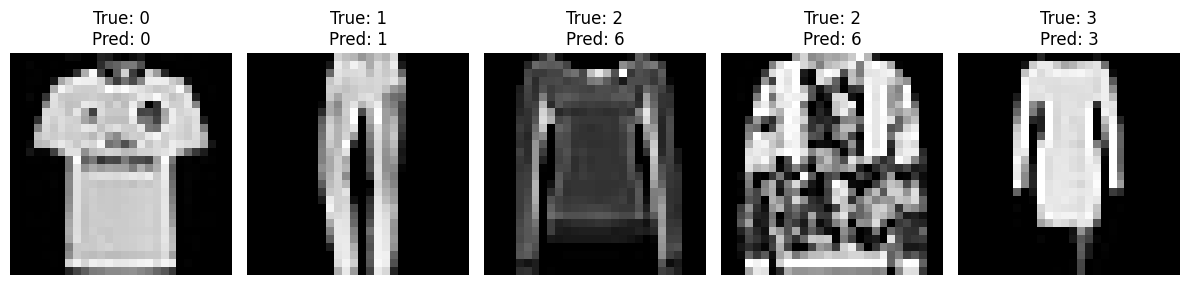

In [12]:
plt.figure(figsize=(12, 3))

for i in range(5):

    plt.subplot(1, 5, i + 1)

    plt.imshow(
        X_test[i].squeeze(),
        cmap="gray"
    )

    plt.title(
        f"True: {y_test[i]}\nPred: {predicted_labels[i]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()